In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device: cuda


# Load and Explore the Data

In [2]:
DATA_PATH = '/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [4]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


# Convert labels to binary

In [5]:
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('After mapping  ->  0 = negative, 1 = positive')
print(df['label'].value_counts())

After mapping  ->  0 = negative, 1 = positive
label
1    25000
0    25000
Name: count, dtype: int64


# Explore Review Lengths

Min length  : 4
Max length  : 2470
Mean length : 231
Median      : 173
Reviews > 500 words: 3903 (7.8%)


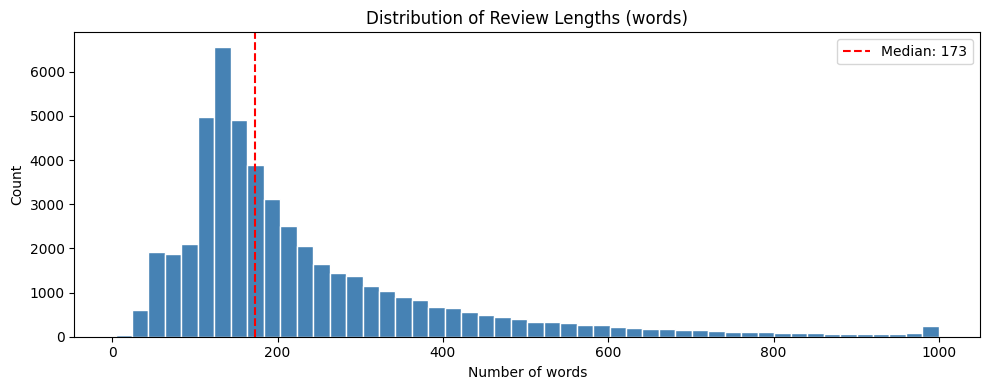

In [6]:
import matplotlib.pyplot as plt

lengths = df['review'].apply(lambda x: len(x.split()))

print(f'Min length  : {lengths.min()}')
print(f'Max length  : {lengths.max()}')
print(f'Mean length : {lengths.mean():.0f}')
print(f'Median      : {lengths.median():.0f}')
print(f'Reviews > 500 words: {(lengths > 500).sum()} ({(lengths > 500).mean()*100:.1f}%)')

plt.figure(figsize=(10, 4))
plt.hist(lengths.clip(upper=1000), bins=50, color='steelblue', edgecolor='white')
plt.axvline(lengths.median(), color='red', linestyle='--',
            label=f'Median: {lengths.median():.0f}')
plt.title('Distribution of Review Lengths (words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(df['review'].iloc[0][:200])

In [7]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)        # remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # keep only letters
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)          # collapse whitespace
    return text

df['clean'] = df['review'].apply(clean_text)

In [8]:
print(df['clean'].iloc[0][:200])

one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br


# Tokenization

In [9]:
from transformers import DistilBertTokenizer

CHECKPOINT = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizer.from_pretrained(CHECKPOINT)

print(f'Vocabulary size: {tokenizer.vocab_size:,}')

Vocabulary size: 30,522


In [10]:
sample  = 'I strongly believe that meditation and mindfulness practices should be included in schools.'
encoded = tokenizer(sample)

print('Input string  :', sample)
print('Token IDs     :', encoded['input_ids'])
print('Decoded tokens:', tokenizer.convert_ids_to_tokens(encoded['input_ids']))

Input string  : I strongly believe that meditation and mindfulness practices should be included in schools.
Token IDs     : [101, 1045, 6118, 2903, 2008, 13804, 1998, 2568, 20938, 6078, 2323, 2022, 2443, 1999, 2816, 1012, 102]
Decoded tokens: ['[CLS]', 'i', 'strongly', 'believe', 'that', 'meditation', 'and', 'mind', '##fulness', 'practices', 'should', 'be', 'included', 'in', 'schools', '.', '[SEP]']


In [11]:
MAX_LEN = 256

encodings = tokenizer(
    list(df['review']),
    truncation = True,
    padding = 'max_length',
    max_length = MAX_LEN,
    return_tensors = 'pt'
)

print('input_ids shape     :', encodings['input_ids'].shape)
print('attention_mask shape:', encodings['attention_mask'].shape)

input_ids shape     : torch.Size([50000, 256])
attention_mask shape: torch.Size([50000, 256])


In [12]:
encodings['input_ids'][0]

tensor([  101,  2028,  1997,  1996,  2060, 15814,  2038,  3855,  2008,  2044,
         3666,  2074,  1015, 11472,  2792,  2017,  1005,  2222,  2022, 13322,
         1012,  2027,  2024,  2157,  1010,  2004,  2023,  2003,  3599,  2054,
         3047,  2007,  2033,  1012,  1026,  7987,  1013,  1028,  1026,  7987,
         1013,  1028,  1996,  2034,  2518,  2008,  4930,  2033,  2055, 11472,
         2001,  2049, 24083,  1998,  4895, 10258,  2378,  8450,  5019,  1997,
         4808,  1010,  2029,  2275,  1999,  2157,  2013,  1996,  2773,  2175,
         1012,  3404,  2033,  1010,  2023,  2003,  2025,  1037,  2265,  2005,
         1996,  8143, 18627,  2030,  5199,  3593,  1012,  2023,  2265,  8005,
         2053, 17957,  2007, 12362,  2000,  5850,  1010,  3348,  2030,  4808,
         1012,  2049,  2003, 13076,  1010,  1999,  1996,  4438,  2224,  1997,
         1996,  2773,  1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,
         1028,  2009,  2003,  2170, 11472,  2004,  2008,  2003, 

In [13]:
encodings['attention_mask'][0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Dataset and DataLoaders

In [14]:
from torch.utils.data import Dataset, DataLoader

class IMDBDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids      = input_ids
        self.attention_mask = attention_mask
        self.labels         = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label'         : self.labels[idx]
        }

In [15]:
from sklearn.model_selection import train_test_split

labels = torch.tensor(df['label'].values, dtype=torch.long)

idx_train, idx_temp = train_test_split(
    range(len(labels)),test_size=0.3,stratify=labels,random_state=SEED
)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.5, stratify=labels[idx_temp], random_state=SEED
)

In [16]:
def make_datasets(indices):
  return IMDBDataset(
      input_ids      = encodings['input_ids'][indices],
      attention_mask = encodings['attention_mask'][indices],
      labels         = labels[indices]
  )

train_ds = make_datasets(idx_train)
val_ds = make_datasets(idx_val)
test_ds = make_datasets(idx_test)

print('Train size:', len(train_ds))
print('Val size  :', len(val_ds))
print('Test size :', len(test_ds))

Train size: 35000
Val size  : 7500
Test size : 7500


In [18]:
train_ds[0]

{'input_ids': tensor([  101,  2065,  2017,  2215,  2000,  2156,  1037,  2995, 10874,  1010,
          9278,  2023,   999,   999,   999,  2009,  1005,  1055,  2025,  2013,
          1996,  2472,  2030, 11167,  1997,  1000,  6978,  1000,  1010,  2987,
          1005,  1056,  3444,  2058, 18908,  2075,  1010,  2058,  4502,  3593,
          1000,  2694,  1000,  5889,  4458,  2125,  2004,  1000,  3340,  1000,
          1010,  1998,  2003,  2025,  1037,  2448,  1997,  1996,  4971,  2569,
          3896, 14753, 16076,  1012,  2612,  2017,  1005,  2222,  2131,  1037,
          2327,  1011, 18624,  1010,  3968,  6292,  1010,  2200,  2844,  1006,
          1999,  4808,  1007,  2664, 26162, 13774, 16313,  2121,  1012,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [19]:
BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 2188 | Val batches: 469 | Test batches: 469


# Full Fine-Tuning

All DistilBERT layers are now **trainable**. We use a much smaller learning rate
(`2e-5`) to nudge the pretrained weights gently — a large learning rate would
destroy the representations learned during pretraining on 3.3 billion words.
This is sometimes called avoiding **catastrophic forgetting**.

**When to use this:** when you have a GPU and at least a few hundred labelled
examples. Full fine-tuning consistently outperforms feature extraction.

In [20]:
import torch.nn as nn
from transformers import DistilBertModel

class SentimentClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        self.distilbert = DistilBertModel.from_pretrained(CHECKPOINT)
        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            self.distilbert.config.hidden_size,
            num_classes
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_hidden_state = outputs.last_hidden_state

        # [CLS] token representation
        pooled_output = last_hidden_state[:, 0, :]

        pooled_output = self.dropout(pooled_output)

        return self.classifier(pooled_output)


# Create the model OUTSIDE the class
model = SentimentClassifier().to(device)

trainable = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

untrainable = sum(
    p.numel() for p in model.parameters()
    if not p.requires_grad
)

print(f"Trainable parameters: {trainable:,}")
print(f"Untrainable parameters: {untrainable:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Trainable parameters: 66,364,418
Untrainable parameters: 0


In [26]:
from torch.optim import AdamW
def train_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask)

        # Calculate loss
        loss = criterion(logits, labels_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item() * labels_batch.size(0)

        # Calculate accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss/total, correct/total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)

        # Forward pass
        logits = model(input_ids, attention_mask)

        # Calculate loss
        loss = criterion(logits, labels_batch)

        # Accumulate loss
        total_loss += loss.item() * labels_batch.size(0)

        # Calculate accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss / total, correct/total

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS  = 3   # Fine-tuning converges quickly; 2-5 epochs is the norm
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    print(f'Epoch {epoch}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}'
          f'val_loss={va_loss:.4f}  val_acc={va_acc:.4f}')

Epoch 1/3  train_loss=0.2707  train_acc=0.8841val_loss=0.2226  val_acc=0.9072
Epoch 2/3  train_loss=0.1574  train_acc=0.9401val_loss=0.2156  val_acc=0.9140
Epoch 3/3  train_loss=0.0818  train_acc=0.9719val_loss=0.3032  val_acc=0.9101


In [38]:
_, test_acc = evaluate(model, test_loader, criterion)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Accuracy: 0.9155  (91.55%)


In [39]:
import os
import json
import torch

# Create artifact directories
ARTIFACT_DIR = "/kaggle/working/artifacts"
TOKENIZER_DIR = os.path.join(ARTIFACT_DIR, "tokenizer")

os.makedirs(TOKENIZER_DIR, exist_ok=True)

# --------------------------------------------------
# 1. Save trained model weights
# --------------------------------------------------
torch.save(
    model.state_dict(),
    os.path.join(ARTIFACT_DIR, "bert_model.pt")
)

# --------------------------------------------------
# 2. Save tokenizer
# --------------------------------------------------
tokenizer.save_pretrained(TOKENIZER_DIR)

# --------------------------------------------------
# 3. Save model configuration
# --------------------------------------------------
config = {
    "checkpoint": CHECKPOINT,
    "num_classes": 2,
    "dropout": 0.3,
    "max_length": MAX_LEN
}

with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Model artifacts saved successfully.")

Model artifacts saved successfully.


In [40]:
!find /kaggle/working/artifacts -type f -printf "%p\n"

/kaggle/working/artifacts/tokenizer/vocab.txt
/kaggle/working/artifacts/tokenizer/special_tokens_map.json
/kaggle/working/artifacts/tokenizer/tokenizer_config.json
/kaggle/working/artifacts/bert_model.pt
/kaggle/working/artifacts/config.json


In [41]:
!ls -lh /kaggle/working/artifacts/bert_model.pt

-rw-r--r-- 1 root root 254M Sep 15 07:16 /kaggle/working/artifacts/bert_model.pt


In [42]:
!cd /kaggle/working && zip -r sentiment_model_artifacts.zip artifacts/

  adding: artifacts/ (stored 0%)
  adding: artifacts/tokenizer/ (stored 0%)
  adding: artifacts/tokenizer/vocab.txt (deflated 53%)
  adding: artifacts/tokenizer/special_tokens_map.json (deflated 42%)
  adding: artifacts/tokenizer/tokenizer_config.json (deflated 75%)
  adding: artifacts/bert_model.pt (deflated 8%)
  adding: artifacts/config.json (deflated 18%)


In [43]:
!ls -lh /kaggle/working/sentiment_model_artifacts.zip

-rw-r--r-- 1 root root 234M Sep 15 07:18 /kaggle/working/sentiment_model_artifacts.zip
